In [22]:
import pandas as pd

In [23]:
dataset=pd.read_csv("50_Startups.csv")

In [24]:
#dataset

In [25]:
dataset=pd.get_dummies(dataset,dtype=int ,drop_first=True)
#dataset

In [26]:
dataset.columns

Index(['R&D Spend', 'Administration', 'Marketing Spend', 'Profit',
       'State_Florida', 'State_New York'],
      dtype='object')

In [27]:
Independent=dataset[['R&D Spend', 'Administration', 'Marketing Spend',
       'State_Florida', 'State_New York']]

In [28]:
#Independent

In [29]:
dependent=dataset[["Profit"]]

In [30]:
#dependent

In [31]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(Independent,dependent,test_size=0.3,random_state=0)

In [32]:
#x_train

In [33]:
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
regressor1=AdaBoostRegressor(random_state=0, n_estimators=100)
regressor2=DecisionTreeRegressor(criterion='poisson', splitter='best')
regressor1=regressor1.fit(x_train,y_train)
regressor2=regressor2.fit(x_train,y_train)


C:\Users\SPPSS\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [34]:
y_pred1=regressor1.predict(x_train).ravel()
y_pred2=regressor2.predict(x_train).ravel()

In [40]:
from sklearn.metrics import r2_score


In [41]:
r_score=r2_score(y_test,y_pred1)
r_score

ValueError: Found input variables with inconsistent numbers of samples: [8, 18]

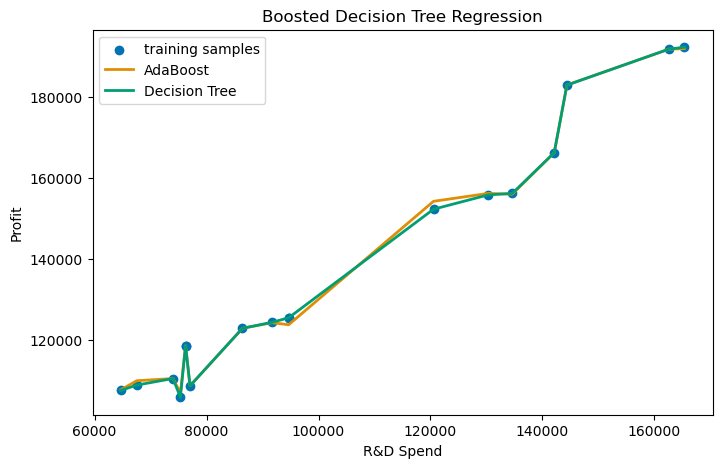

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

colors = sns.color_palette("colorblind")

x = x_train.iloc[:, 0].values
y = y_train.iloc[:, 0].values

idx = np.argsort(x)

x = x[idx]
y = y[idx]
y_pred1 = y_pred1[idx]
y_pred2 = y_pred2[idx]

plt.figure(figsize=(8,5))

plt.scatter(x, y, color=colors[0], label="training samples")
plt.plot(x, y_pred1, color=colors[1], label="AdaBoost", linewidth=2)
plt.plot(x, y_pred2, color=colors[2], label="Decision Tree", linewidth=2)

plt.xlabel("R&D Spend")
plt.ylabel("Profit")
plt.title("Boosted Decision Tree Regression")
plt.legend()

plt.show()